# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откроем файл с данными и изучим общую информацию

**1.1 Импортируем библиотеки. Считаем данные из csv-файла в датафрейм и сохраним в переменную `data`. Путь к файлу:**
    
`/datasets/real_estate_data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

**1.2 Выведем первые 20 строчек датафрейма `data` на экран.**

In [3]:
pd.set_option('display.max_columns', None)
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


**1.3 Выведем основную информацию о датафрейме с помощью метода `info()`.**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

**1.4 Построим гистограммы для всех числовых столбцов.**

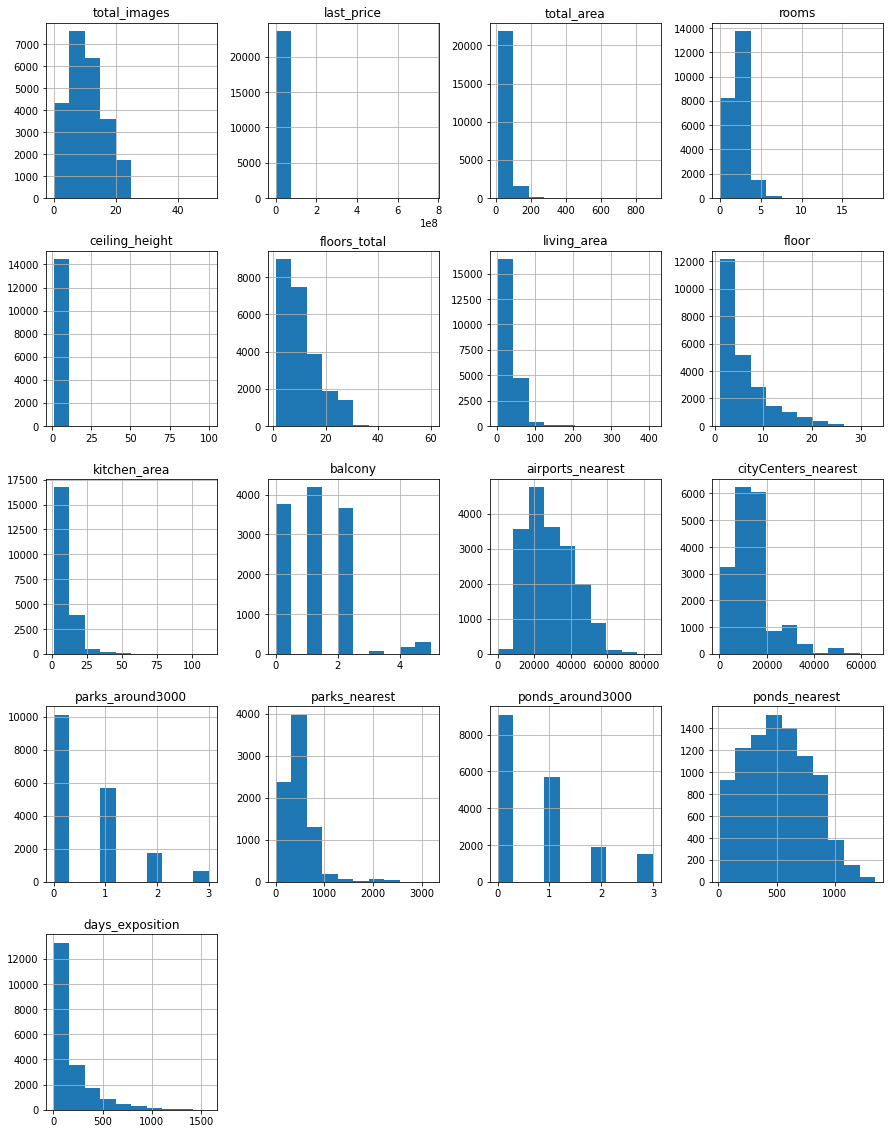

In [5]:
data.hist(figsize=(15, 20));

**Вывод: В данных 23699 записи. Для целого ряда столбцов есть пропущенные значения и некорректный тип данных. По гисторгаммам видно, что в данных есть аномальные значения. Требуется предобработка данных.** 

### Выполним предобработку данных

**2.1 Приведем имена столбцов к единому стилю.**

In [6]:
data = data.rename(columns={'cityCenters_nearest': 'city_centers_nearest', 
                            'parks_around3000': 'parks_around_3000', 
                            'ponds_around3000': 'ponds_around_3000'})

**2.2 Выведем количество пропущенных значений для каждого столбца.**

In [7]:
data.isnull().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Пропуски могут быть связаны с "человеческим" фактором (пользователь мог не указать определенный параметр, предполагая его отсутствие: например, количество балконов или принадлежность к апартаментам, либо не знает какие-то параметры: например площадь помещений), а могут быть связаны с техническими ошибками при загрузке данных.

В 14 столбцах из 22 присутствуют пропуски:

- ceiling_height (высота потолков): почти 40% объявлений не имеют информацию о высоте потолков (это очень большое количество), заменим пропущенные значения на медианное значение по всему датасету;

- floors_total (всего этажей в доме): пропусков мало, на исследование не повлияют, пропуски оставляем;

- living_area (жилая площадь): количество пропусков менее 10%, но данные по этому столбцу нужны для исследования, однако заполнить значения нечем, пропуски оставляем;

- is_apartment (признак апартаментов): так как это логический тип данных, пропуски можно заменить на False;

- kitchen_area (площадь кухни) количетство пропусков менее 10%, но данные по этому столбцу нужны для исследования, однако заполнить значения нечем, пропуски оставляем;

- balcony (число балконов): вероятно, пользователи при отсутствии балконов их не указывают, в таком случае заменим пропуски нулями;

- locality_name (название населенного пункта): количество пропусков мало, на исследование не повлияют, оставим пропуски;

- airports_nearest (расстояние до ближайшего аэропорта): вероятно, пропуски возникли в связи с отсутствием информации в картографических данных, пропуски в столбце на задачи исследования не влияют, оставим их;

- city_centers_nearest (расстояние до центра города): вероятно, пропуски возникли в связи с отсутствием информации в картографических данных, пропуски в столбце на задачи исследования не влияют, оставим их;

- parks_around_3000 (число парков в радиусе 3 км): возможно, для этих объектов не была получена информация на основе картографических данных, пропуски в столбце на задачи исследования не влияют, оставим их;

- parks_nearest (расстояние до ближайшего парка): вероятно, не была получена информация на основе картографических данных, пропуски в столбце на задачи исследования не влияют, оставим их;

- ponds_around_3000 (число водоемов в радиусе 3 км): вероятно, для этих объектов не была получена информация на основе картографических данных, пропуски в столбце на задачи исследования не влияют, оставим их;

- ponds_nearest (расстояние до ближайшего водоема): вероятно, информация на основе картографических данных не была получена, пропуски в столбце на задачи исследования не влияют, оставим их;

- days_exposition (сколько дней было размещено объявление): вероятно, это техническая ошибка, которая произошла в момент сбора/выгрузки данных, данные этого столбца важны для исследования, заполнить значения нечем, оставим пропуски.

In [8]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())
data['is_apartment'] = data['is_apartment'].fillna(False)
data['balcony'] = data['balcony'].fillna(0)
# проверка
data.isnull().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total               86
living_area              1903
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             2278
balcony                     0
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

**2.3 Преобразуем типы данных в некоторых столбцах.**

Требуется преобразование данных в следующих столбцах:

- first_day_exposition (дата публикации) - тип даты и времени;
- is_apartment (признак апартаментов) - булевый тип;
- balcony (количество балконов) - целочисленный тип.

In [9]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['is_apartment'] = data['is_apartment'].astype(bool)
data['balcony'] = data['balcony'].astype(int)


# проверка
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

**2.4 Изучим уникальные значения в столбце с названиями и устраним неявные дубликаты.** 

In [10]:
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё','е')
    .replace(['поселок', 'при железнодорожной станции ', 'платформа ', 'садоводческое некоммерческое товарищество ',
             'садовое товарищество ', 'станции ', 'село ', 'пансионат ', 'городского типа ',
             'деревня ', 'городской поселок ', 'городской ', 'коттеджный ' ], '', regex=True)
)

**Вывод: Cделали предобработку данных, а именно: привели имена столбцов к единому стилю, обработали пропуски, изменили типы данных, а также обработали неявные дубликаты.**

### Добавим в таблицу новые столбцы

- price_one_square_meter: цена одного квадратного метра;
- exposition_weekday: день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- exposition_month: месяц публикации объявления;
- exposition_year: год публикации объявления;
- floor_category: тип этажа квартиры (значения — «первый», «последний», «другой»);
- city_centers_nearest_km: расстояние до центра города в километрах (переведите из м в км и округлите до целых значений).

In [11]:
# Добавляем столбец со стоимостью квадратного метра (sm_price) и округляем его до двух знаков после запятой
data['price_one_square_meter'] = data['last_price'] / data['total_area']
data['price_one_square_meter'] = data['price_one_square_meter'].round(2)

# Добавляем столбцы дня недели, месяца и года
data['exposition_weekday'] = data['first_day_exposition'].dt.weekday
data['exposition_month'] = data['first_day_exposition'].dt.month
data['exposition_year'] = data['first_day_exposition'].dt.year

# Функция для категоризации этажности в доме
def get_floor_category(row):
    floor = row['floor']
    floors_total = row['floors_total']
    if floor == 1:
        return 'первый'
    elif floor == floors_total:
        return 'последний'
    else:
        return 'другой'

# Добавляем столбец с категорией этажа квартиры
data['floor_category'] = data.apply(get_floor_category, axis=1)

# Добавляем столбец с расстоянием до центра
data['city_centers_nearest_km'] = round(data['city_centers_nearest'] / 1000)

**Вывод: Добавили необходимые столбцы и произвели расчеты по ним. Отметим, что из-за пропусков в исходных данных, в расчетных значениях также есть пропуски. Например, в некоторых случаях мог не совсем корректно определяться тип этажности квартиры (в случае если отсутствует информация об этажности дома). Учитывая то, что доля возможных неточностей крайне мала, на результаты исследования они не повлияют.**

### Проведите исследовательский анализ данных

**4.1 Изучим перечисленные ниже параметры объектов и построим отдельные гистограммы для каждого из этих параметров.**

Список параметров:
- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков;
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка

**4.1.1 Общая площадь**

Посмотрим описательную часть для этого столбца.

In [12]:
print(data['total_area'].describe())

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64


Оставим значения от минимального 12 до 100 кв. метров и построим гистограмму.

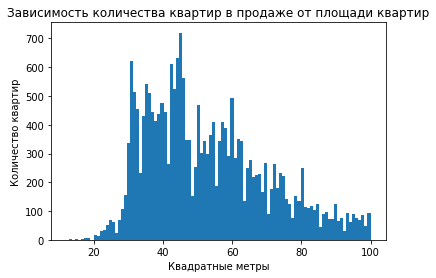

In [13]:
plt.hist(data['total_area'], bins=100, range=(12,100))
plt.title('Зависимость количества квартир в продаже от площади квартир')
plt.xlabel('Квадратные метры')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, на рынке самое большое предложение квартир с общей площадью от 40 до 69 кв. метров с максимумом около 52 кв. метров.

**4.1.2 Жилая площадь**

Посмотрим описательную часть для этого столбца.

In [14]:
print(data['living_area'].describe())

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64


Оставим значения от минимального 2 до 50 кв. метров и построим гистограмму.

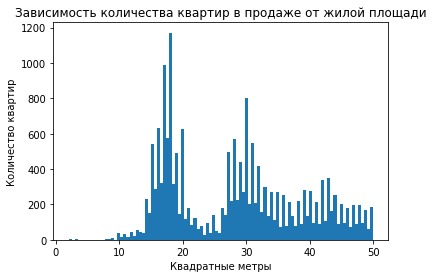

In [15]:
plt.hist(data['living_area'], bins=100, range=(2,50))
plt.title('Зависимость количества квартир в продаже от жилой площади')
plt.xlabel('Квадратные метры')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, больше всего продают квартир с жилой площадью около 18 кв. м и 30 кв. метров, при этом прослеживается спад предложений в средней зоне 23-25 кв. метра.

**4.1.3 Площадь кухни**

Посмотрим описательную часть для этого столбца.

In [16]:
print(data['kitchen_area'].describe())

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64


Оставим значения от 6 до 12 кв. метров и построим гистограмму.

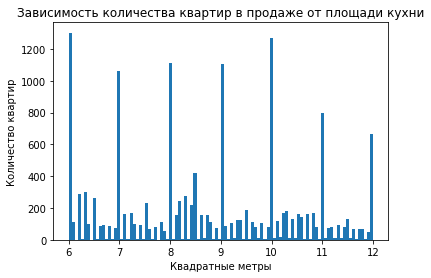

In [17]:
plt.hist(data['kitchen_area'], bins=100, range=(6,12))
plt.title('Зависимость количества квартир в продаже от площади кухни')
plt.xlabel('Квадратные метры')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, прослеживается тенденция что больше всего предложений с площадью кухни в 6 метров затем 10 и чередом 7,8,9 кв. метров, при этом в анкетах заметны явные всплески на целых числах.

**4.1.4 Цена объекта**

Посмотрим описательную часть для этого столбца.

In [18]:
print(data['last_price'].describe())

count    2.369900e+04
mean     6.541549e+06
std      1.088701e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64


Выберем диапазон значений и построим гистограмму.

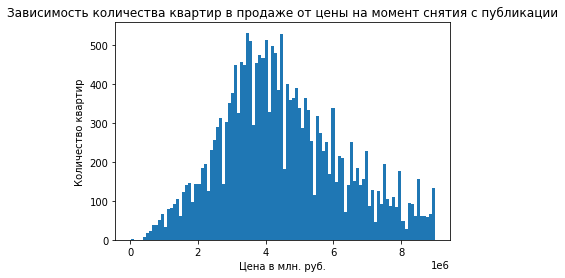

In [19]:
plt.hist(data['last_price'], bins=100, range=(1.219000e+04,9.00000e+06))
plt.title('Зависимость количества квартир в продаже от цены на момент снятия с публикации')
plt.xlabel('Цена в млн. руб.')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, наиболее часто цена объекта составляет 3,8 - 4,2 миллниона рублей.

**4.1.5 Количество комнат**

Посмотрим описательную часть для этого столбца.

In [20]:
print(data['rooms'].describe())

count    23699.000000
mean         2.070636
std          1.078405
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64


Выберем значения от минимального 0 до 7 и построим гистограмму.

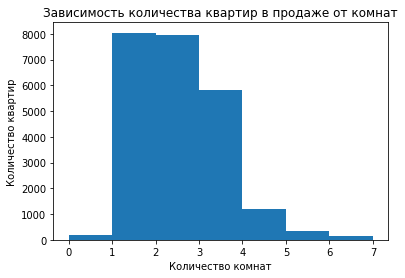

In [21]:
plt.hist(data['rooms'], bins=7, range=(0,7))
plt.title('Зависимость количества квартир в продаже от комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, среди предложений больше всего однокомнатных квартир, с увеличением комнат количество предложений снижается почти линейно.

**4.1.6 Высота потолков**

Посмотрим описательную часть для этого столбца.

In [22]:
print(data['ceiling_height'].describe())

count    23699.000000
mean         2.724358
std          0.988298
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64


Выберем значения от 2 до 4 и построим гистограмму.

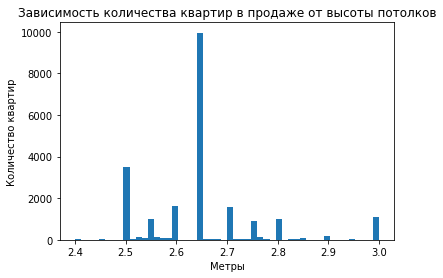

In [23]:
plt.hist(data.query('(ceiling_height > 2) & (ceiling_height < 4)')['ceiling_height'], bins=50, range=(2.4,3))
plt.title('Зависимость количества квартир в продаже от высоты потолков')
plt.xlabel('Метры')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, для большинства квартир высота составляет 2.65 метров.

**4.1.7 Тип этажа квартиры**

Посмотрим на зависимость цены квартиры от ее "этажности".

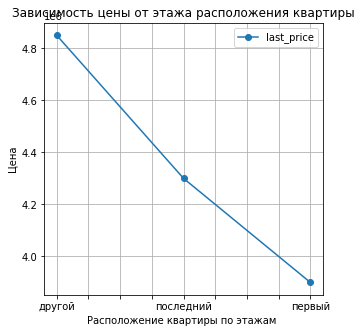

In [24]:
(
    data.pivot_table(index='floor_category', values='last_price', aggfunc='median').sort_values(by='last_price', ascending=False)
    .plot(grid=True, style='o-', figsize=(5, 5), title='Зависимость цены от этажа расположения квартиры')
)
plt.xlabel('Расположение квартиры по этажам ')
plt.ylabel('Цена')
plt.show()

Посмотрим на зависимость количества квартир от их "этажности".

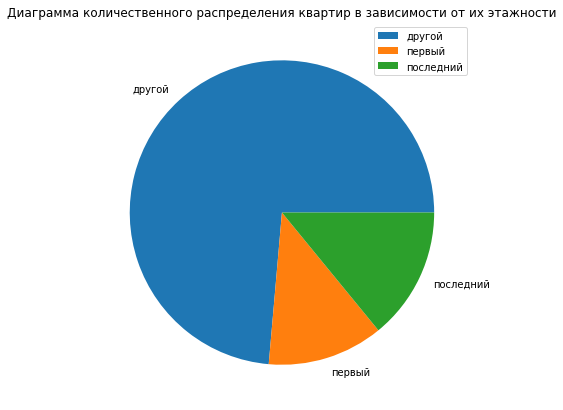

In [25]:
data.pivot_table(index='floor_category',values='last_price',aggfunc='count') \
  .plot.pie(y='last_price', figsize=(10,7), label='', title='Диаграмма количественного распределения квартир в зависимости от их этажности')

plt.show()

Как видно из приведенных выше данных, менее востребованными являются квартиры на "первом" и "последнем" этаже.

**4.1.8 Количество этаже в доме**

Посмотрим описательную часть для этого столбца.

In [26]:
print(data['floors_total'].describe())

count    23613.000000
mean        10.673824
std          6.597173
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64


Выберем значения от минимального 1 до 30 и построим гистограмму.

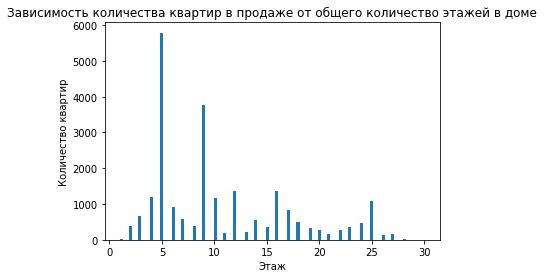

In [27]:
plt.hist(data['floors_total'], bins=100, range=(1,30))
plt.title('Зависимость количества квартир в продаже от общего количество этажей в доме')
plt.xlabel('Этаж')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, больше всего предложений о продаже квартир в пятиэтажных домах, а затем - в девятиэтажках.

**4.1.9 Расстояние до центра города**

Посмотрим описательную часть для этого столбца.

In [28]:
print(data['city_centers_nearest'].describe())

count    18180.000000
mean     14191.277833
std       8608.386210
min        181.000000
25%       9238.000000
50%      13098.500000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64


Выберем значения от 0 до 25000 и построим гистограмму.

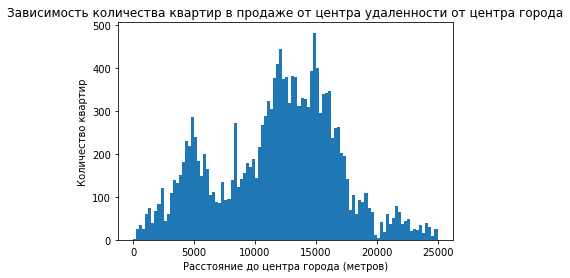

In [29]:
plt.hist(data['city_centers_nearest'], bins=100, range=(0,25000))
plt.title('Зависимость количества квартир в продаже от центра удаленности от центра города')
plt.xlabel('Расстояние до центра города (метров)')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных, больше всего предложений о продаже в спальных районах на окраинах города (на расстоянии 12000 -15000 метров)), и значительным всплеском на расстоянии в 5000 метров от центра города.

**4.1.10 Расстояние до ближайшего парка**

Посмотрим описательную часть для этого столбца.

In [30]:
print(data['parks_nearest'].describe())

count    8079.000000
mean      490.804555
std       342.317995
min         1.000000
25%       288.000000
50%       455.000000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64


Выберем значения от 100 до 800 и построим гистограмму.

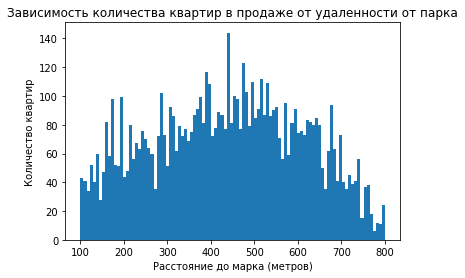

In [31]:
plt.hist(data['parks_nearest'], bins=100, range=(100,800))
plt.title('Зависимость количества квартир в продаже от удаленности от парка')
plt.xlabel('Расстояние до марка (метров)')
plt.ylabel('Количество квартир')
plt.show()

Как видно из приведенных выше данных, количество предложений не сильно зависит от удаленности от ближайшего парка, среднее расстояние до парка премерно составляет 200 - 700 метров.

**Общий вывод по разделу:**

На рынке самое большое предложение квартир с общей площадью от 40 до 69 кв. метров с максимумом около 52 кв. метров.
Больше всего продают квартир с жилой площадью около 18 кв. м и 30 кв. метров, при этом прослеживается спад предложений в средней зоне 23 кв. метра.
Прослеживается тенденция, что больше всего предложений с площадью кухни в 6 метров, а затем 10 кв. метров.
Наиболее часто встречающаяся цена квартиры составляет 3,8 - 4,2 миллниона.
Среди предложений больше всего однокомнатных квартир, с увеличением комнат количество предложений снижается почти линейно.
Среди большинства предложений высота составляет 2.65 метров.
Менее ценными считаются квартиры на "первом" этаже, на круговой диаграмме заметно, что общее количество предложений "первого" и "последнего" этажа составляет не более 25% от общего количества.
Больше всего предложений о продаже квартир в пятиэтажных домах, а затем - в девятиэтажках.
Больше всего предложений о продаже в спальных районах на окраинах города (на расстоянии 12000 -15000 метров), со всплеском на расстоянии в 5000 метров от центра города.
Количество предложений не сильно зависит от удаленности от ближайшего парка, среднее расстояние до парка премерно составляет 200 - 700 метров.

**Таким образом, среднестатистическим предложением является квартира в пятиэтажном доме средней площадью 52 кв. метра с кухней в 6 кв. метров, высотой потолков 2,65 метра (однокомнатная или двухкомнатная), на удалении 13 км. от центра города.**

**4.2 Изучим, как быстро продавались квартиры**

Посмотрим описательную часть для этой информации.

In [32]:
print(data['days_exposition'].describe())

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64


Выберем значения от 0 до 250 и построим гистограмму.

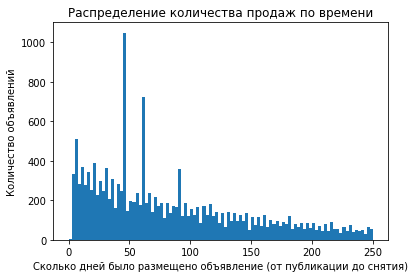

In [33]:
plt.hist(data['days_exposition'], bins=100, range=(0,250))
plt.title('Распределение количества продаж по времени')
plt.xlabel('Сколько дней было размещено объявление (от публикации до снятия)')
plt.ylabel('Количество объявлений')
plt.show()

Среднее значение продажи составляет 180 дня, при этом медианное значение составляет 95 дня, оно более точно характеризует среднее время продажи, так как не зависит от выбрасов и нестандартных значений.

В среднем продажа среднестатистичекой квартиры занимает 2-3 месяца в зависимотсти от сопутствующих факторов(площади, цены, удаленности от центра).

Быстрыми продажами можно считать продажи состоявшиеся за 45 днней (в первом квартиле), а необычно долгие продажи после 232 дня и более (после 3 квартиля), которые вообще могут быть не проданными.

**4.3 Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта.**

Изучим зависимость значение цены last_price от значений следующих параметров с использованием коэффициента корреляции:
- total_area - общая площадь;
- living_area - жилая площадь;
- kitchen_area - площадь кухни;
- rooms - количество комнат;
- floor_category - этажности квартиры;
- exposition_weekday - день публикации;
- exposition_month - месяц публикации;
- exposition_year - год публикации.

Для анализа взаимосвязей отфильтруем редкие и выбивающиеся значения.

In [34]:
# Функция для подсчета границ с учетом 1.5 размаха
def quartile_range(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    dfq = df.loc[(df[column] < q3 + 1.5*iqr) & (df[column] > q1 - 1.5*iqr), column]
    return dfq
# Столбцы с выбросами
list_features = ['last_price', 'total_area', 'living_area', 'kitchen_area', 'rooms']
for col in list_features:
    data[col] = quartile_range(data, col)

# Возвращаем в целочисленный тип число комнат
data['rooms'] = data['rooms'].fillna(0).astype(int)

# Изучаем, есть ли выбивающиеся значения
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,price_one_square_meter,exposition_weekday,exposition_month,exposition_year,city_centers_nearest_km
count,23699.000000,2.163800e+04,22459.000000,23699.000000,23699.000000,23613.000000,21023.000000,23699.000000,20219.000000,23699.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000,2.369900e+04,23699.000000,23699.000000,23699.000000,18180.000000
mean,9.858475,4.839970e+06,54.364907,2.013545,2.724358,10.673824,31.552247,5.892358,9.504662,0.591080,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634,9.942166e+04,2.569307,6.400101,2017.367146,14.184818
std,5.682529,2.217341e+06,19.385325,0.986846,0.988298,6.597173,13.941065,4.885249,3.125573,0.959298,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988,5.030680e+04,1.789082,3.491561,1.039771,8.616194
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000,1.118300e+02,0.000000,1.000000,2014.000000,0.000000
25%,6.000000,3.300000e+06,39.400000,1.000000,2.600000,5.000000,18.400000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000,7.658547e+04,1.000000,3.000000,2017.000000,9.000000
50%,9.000000,4.400000e+06,50.100000,2.000000,2.650000,9.000000,30.000000,4.000000,9.000000,0.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000,9.500000e+04,3.000000,6.000000,2017.000000,13.000000
75%,14.000000,6.000000e+06,65.600000,3.000000,2.700000,16.000000,41.000000,8.000000,11.100000,1.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000,1.142563e+05,4.000000,10.000000,2018.000000,16.000000
max,50.000000,1.189440e+07,114.600000,5.000000,100.000000,60.000000,77.800000,33.000000,19.450000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000,1.907500e+06,6.000000,12.000000,2019.000000,66.000000


Проанализируем зависимости.

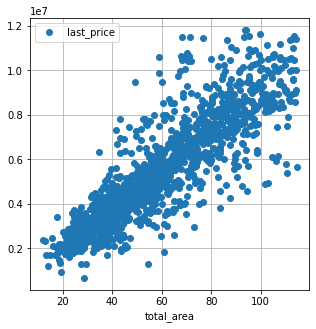

Корреляция цены и общей площади: 

            last_price  total_area
last_price    1.000000    0.905255
total_area    0.905255    1.000000 



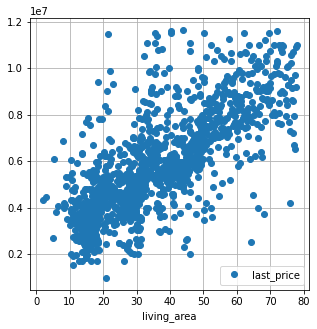

Корреляция цены и жилой площади: 

             last_price  living_area
last_price     1.000000     0.725857
living_area    0.725857     1.000000 



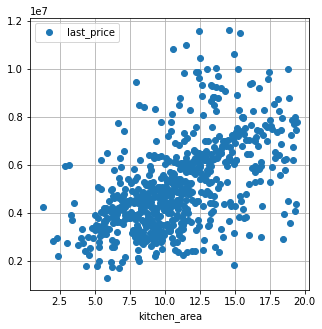

Корреляция цены и площади кухни: 

              kitchen_area  last_price
kitchen_area      1.000000    0.418146
last_price        0.418146    1.000000 



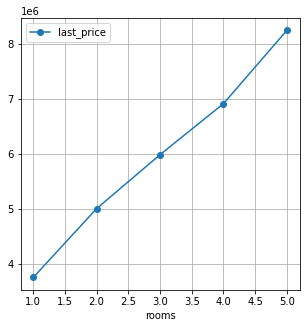

Корреляция цены и числа комнат: 

            last_price     rooms
last_price    1.000000  0.538349
rooms         0.538349  1.000000 



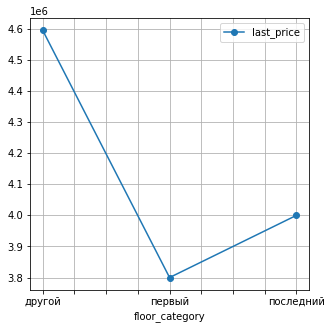

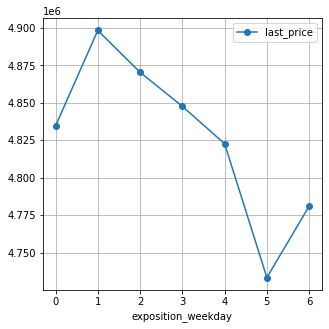

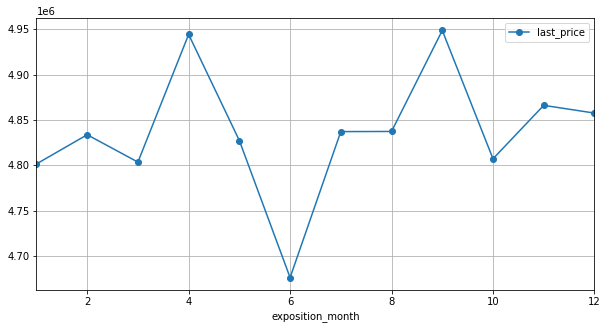

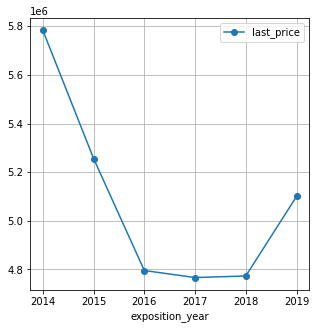

In [35]:
# Зависимость цены от общей площади
(
    data.pivot_table(index='total_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.show()
print('Корреляция цены и общей площади:','\n')
print(data.pivot_table(index='floor', values=['total_area', 'last_price']).corr(),'\n')

# Зависимость цены от жилой площади
(
    data.pivot_table(index='living_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.show()
print('Корреляция цены и жилой площади:','\n')
print(data.pivot_table(index='floor', values=['living_area', 'last_price']).corr(),'\n')

# Зависимость цены от площади кухни
(
    data.pivot_table(index='kitchen_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.show()
print('Корреляция цены и площади кухни:','\n')
print(data.pivot_table(index='floor', values=['kitchen_area', 'last_price']).corr(),'\n')


# Зависимость цены от числа комнат
(
    data.query('rooms > 0').pivot_table(index='rooms', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.show()
print('Корреляция цены и числа комнат:','\n')
print(data.query('rooms > 0').pivot_table(index='floor', values=['rooms', 'last_price']).corr(),'\n')

# Зависимость цены от этажа
(
    data.pivot_table(index='floor_category', values='last_price', aggfunc='median')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.show()

# Зависимость от дня размещения
(
    data.pivot_table(index='exposition_weekday', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.show()
# Зависимость от месяца размещения
(
    data.pivot_table(index='exposition_month', values='last_price')
    .plot(grid=True, style='o-', xlim=(1,12), figsize=(10, 5))
)
plt.show()
# Зависимость от года размещения
(
    data.pivot_table(index='exposition_year', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.show()

**Выводы:**

- Чем больше общая площадь, тем выше стоимость. Корреляция этих параметров крайне высокая. 
- Чем больше площадь кухни, тем выше стоимость. Но взаимосвязь этих параметров меньше.
- Зависимость стоимости от жилой площади наименьшая (бывают дорогие квартиры с небольшими комнатами, но большими кухнями).
- Число комнат влияет на цену (больше комнат -> больше цена).
- Первый этаж непосредственно влияет на стоимость квартиры - в среднем квартиры на 1-м этаже значительно дешевле. Чуть дороже последний этаж. Наибольшая стоимость у квартир, расположенных не на 1-м и не на последнем этаже.
- Зависимости стоимости от времени публикации: день недели (дороже всего квартиры, опубликованные в среду и пятницу, дешевле всего - в субботу), месяц (дороже всего квартиры, продающиеся с апреля, дешевле всего - с июня), год (квартиры очень сильно подешевели в 2016-2018 годах, что, вероятно, вызвано некоторым кризисом 2014-2015 годов, в 2019 году цены снова стали повышаться, т.к. экономика и зарплаты скорее на подъёме).


**4.4 Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений**

In [36]:
price_sm_name = data.pivot_table(index='locality_name', values='last_price', aggfunc=['count'])
price_sm_name.columns = ['count']
price_sm_name = price_sm_name.sort_values(by='count', ascending=False).head(10)
price_sm_name['price_one_square_meter'] = data.pivot_table(index='locality_name', values='price_one_square_meter').round(2)
price_sm_name.sort_values(by='price_one_square_meter', ascending=False)

,count,price_one_square_meter
locality_name,,
Санкт-Петербург,13737,114849.01
Пушкин,338,103125.82
Кудрово,470,95324.93
Парголово,327,90175.91
Мурино,556,85681.76
Шушары,440,78677.36
Колпино,336,75424.58
Гатчина,305,68746.15
Всеволожск,397,68654.47


**Вывод:**

Наибольшая средняя стоимость квадратного метра в Санкт-Петербурге. Затем идет Пушкин, что, вероятно, вызвано хорошей застройкой и большим количеством парков. Затем идут районы, фактически являющиеся Санкт-Петербургом и непосредственно к нему примыкают. Из топ-10 наименьшая стоимость в Гатчине и Всеволожске, из которых далеко ехать до Санкт-Петербурга, а также не большой по численности населения Выборг, расположенный на большом расстоянии от Санкт-Петербурга.

**4.5 Выделим квартиры в Санкт-Петербурге и вычислим их среднюю стоимость на разном удалении от центра**

In [37]:
data.query('locality_name == "Санкт-Петербург"')['city_centers_nearest_km'].describe()

count    15660.000000
mean        11.596041
std          4.863594
min          0.000000
25%          8.000000
50%         12.000000
75%         15.000000
max         29.000000
Name: city_centers_nearest_km, dtype: float64

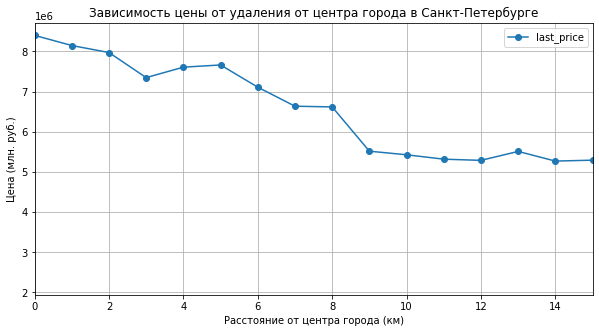

In [38]:
(
    data.query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_km', values='last_price')
    .plot(grid=True, style='o-', xlim=(0,15), figsize=(10, 5))
)
plt.title('Зависимость цены от удаления от центра города в Санкт-Петербурге')
plt.xlabel('Расстояние от центра города (км)')
plt.ylabel('Цена (млн. руб.)')
plt.show()

**Вывод**

Самые дорогие квартиры в центре города и их стоимость уменьшается c увеличением расстояния от центра города до 9 километров, далее стоимость не зависит от удаления.

### Напишите общий вывод

В процессе исследования объявлений о продаже квартир были выполнены следующие этапы и сделаны выводы:
1. Была изучена общая информация о данных:
- в данных 23699 записи;
- для целого ряда столбцов есть пропущенные значения и некорректный тип данных;
- по гисторгаммам видно, что в данных есть аномальные значения;
- данные признаны полными и достаточными для исследования.
2. Выполнена предобработка данных:
- переименовано название некоторых столбцов в соответствии с лучшими практиками;
- заполнены пропуски в таблице;
- изменен тип данных, в соответствии с данными находящимися в столбцах.
- Сделан вывод о причинах появления пропусков: человеческий фактор, технические ошибки.
3. Добавлены новые столбцы в таблицу для проведения следующего этапа анализа
- price_one_square_meter: цена одного квадратного метра;
- exposition_weekday: день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- exposition_month: месяц публикации объявления;
- exposition_year: год публикации объявления;
- floor_category: тип этажа квартиры (значения — «первый», «последний», «другой»);
- city_centers_nearest_km: расстояние до центра города в километрах (переведите из м в км и округлите до целых значений).
4. Проведен исследовательский анализ данных:
- изучены и описаны параметры:
    - среднестатистическое предложение - квартира в пятиэтажном доме средней площадью 52 кв. метра с кухней в 6 кв. метров, высотой потолков 2,65 метра (однокомнатная или двухкомнатная), на удалении 13 км от центра города;
- изучено, как быстро продавались квартиры?
    - среднее значение продажи составляет 180 дня, при этом медианное значение составляет 95 дня, оно более точно характеризует среднее время продажи, так как не зависит от выбросов и нестандартных значений;
    - в среднем продажа средне статистической квартиры занимает 2-3 месяца в зависимости от сопутствующих факторов(площади, цены, удалённости от центра);
    - быстрыми продажами можно считать продажи состоявшиеся за 45 дней (в первом квартиле), а необычно долгие продажи после 232 дня и более (после 3 квартиля), которые могут совсем не продаваться.
- определены факторы, которые больше всего влияют на общую (полную) стоимость квартиры:
    - чем больше общая площадь, тем выше стоимость (корреляция этих параметров крайне высокая);
    - чем больше площадь кухни, тем выше стоимость (взаимосвязь этих параметров меньше);
    - зависимость стоимости от жилой площади наименьшая (бывают дорогие квартиры с небольшими комнатами, но большими кухнями);
    - число комнат влияет на цену (больше комнат -> больше цена);
    - первый этаж непосредственно влияет на стоимость квартиры: в среднем квартиры на 1-м этаже значительно дешевле, чуть дороже последний этаж, наибольшая стоимость у квартир, расположенных не на 1-м и не на последнем этаже;
    - зависимости стоимости от времени публикации: день недели (дороже всего квартиры, опубликованные в среду и пятницу, дешевле всего - в субботу), месяц (дороже всего квартиры, продающиеся с апреля, дешевле всего - с июня), год (квартиры очень сильно подешевели в 2016-2018 годах, что, вероятно, вызвано некоторым кризисом 2014-2015 годов, в 2019 году цены снова стали повышаться, т.к. экономика и зарплаты скорее на подъёме).
- посчитана средняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений:
    - наибольшая средняя стоимость квадратного метра, как и ожидалось, в Санкт-Петербурге, затем идёт Пушкин, что, вероятно, вызвано хорошей застройкой и большим количеством парков, затем идут районы, фактически являющиеся Санкт-Петербургом и непосредственно к нему примыкают. Из топ-10 наименьшая стоимость в Гатчине и Всеволожске, из которых далеко ехать до Санкт-Петербурга, а также небольшой по численности населения Выборг, расположенный на большом расстоянии от Санкт-Петербурга;
- вычислена средняя стоимость квартиры на разном удалении от центра Санкт-Петербурга:
    - самые дорогие квартиры в центре города и их стоимость уменьшается c увеличением расстояния от центра города до 9 километров, далее стоимость не зависит от удаления.

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.